<img src="./mse_logo.png" width="340" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

## Data Cleaning and Integration
### (i) Missing values and np.nan


What are missing values? How do they differ from np.nan? How can we handle them?

In real datasets, we often encounter missing values, which can occur due to various reasons such as data collection errors, non-responses in surveys, or simply because certain information was not available at the time of data gathering. Missing values can be represented in different ways, such as empty strings, null values, or specific placeholders like 'NA' or 'NULL'.

Numpy shows missing values as `np.nan` which stands for "Not a Number".

In [22]:
import numpy as np

x = np.nan
print(x)

nan



The data type of `np.nan` is `float`.

The characteristics of `np.nan` is that it is not equal to anything, including `itself`.

In [23]:
print(np.nan == np.nan)

False


Pandas DataFrame example with missing values:


In [24]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "temperature": [18, 20, np.nan, 22],
    "humidity": [60, np.nan, 65, 70]
})

print(df)

   temperature  humidity
0         18.0      60.0
1         20.0       NaN
2          NaN      65.0
3         22.0      70.0


So because `np.nan` is commen in datasets, the question is how to detect and handle it.


- Detection using the function np.isna[https://numpy.org/devdocs/reference/generated/numpy.isnan.html]

In [25]:
value = np.nan

print(np.isnan(value))

True


In [26]:
import numpy as np

data = np.array([10, 15, np.nan, 20, np.nan])

missing = np.isnan(data)

print(missing)

[False False  True False  True]


Findining missing data in a DataFrame:

In [27]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "temperature": [18, 20, np.nan, 22],
    "humidity": [60, np.nan, 65, 70]
})

print(df)

df.isna()

print("Sum of missing values in each column:")
df.isna().sum()

   temperature  humidity
0         18.0      60.0
1         20.0       NaN
2          NaN      65.0
3         22.0      70.0
Sum of missing values in each column:


temperature    1
humidity       1
dtype: int64

So this was the example of missing values and `np.nan` in Python. But what about other programming languages? How do they represent missing values?



| Language                    | Missing Value Representation | Example                                  | Notes                                                                                                                       |
| --------------------------- | ---------------------------- | ---------------------------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **Python (NumPy / pandas)** | `np.nan`, `None`, `pd.NA`    | `np.nan`                                 | `np.nan` is a floating-point missing value; `None` is a general null object; `pd.NA` is used in newer pandas nullable types |
| **Python (plain)**          | `None`                       | `x = None`                               | Represents absence of a value                                                                                               |
| **R**                       | `NA`, `NaN`, `NULL`          | `x <- NA`                                | `NA` = missing value, `NaN` = undefined numeric result, `NULL` = empty object                                               |
| **SQL**                     | `NULL`                       | `SELECT * FROM table WHERE col IS NULL;` | Cannot use `= NULL`; must use `IS NULL`                                                                                     |
| **JavaScript**              | `null`, `undefined`, `NaN`   | `let x = null;`                          | `null` = intentional empty value, `undefined` = not assigned                                                                |
| **Java**                    | `null`                       | `String x = null;`                       | Only for objects, not primitive types                                                                                       |
| **C#**                      | `null`, `Nullable<T>`        | `int? x = null;`                         | Nullable types allow primitives to be null                                                                                  |
| **C / C++**                 | `NULL` / `nullptr`           | `int* p = NULL;`                         | Represents a null pointer                                                                                                   |
| **Julia**                   | `missing`, `nothing`, `NaN`  | `x = missing`                            | `missing` is preferred for missing data                                                                                     |
| **MATLAB**                  | `NaN`                        | `x = NaN`                                | Used for missing numeric values                                                                                             |
| **Go**                      | `nil`                        | `var p *int = nil`                       | Used for pointers, slices, maps, interfaces                                                                                 |
| **Rust**                    | `Option<T>` (`None`)         | `let x: Option<i32> = None;`             | Missing values handled through the type system                                                                              |


Short excurse why handling missing values is important:

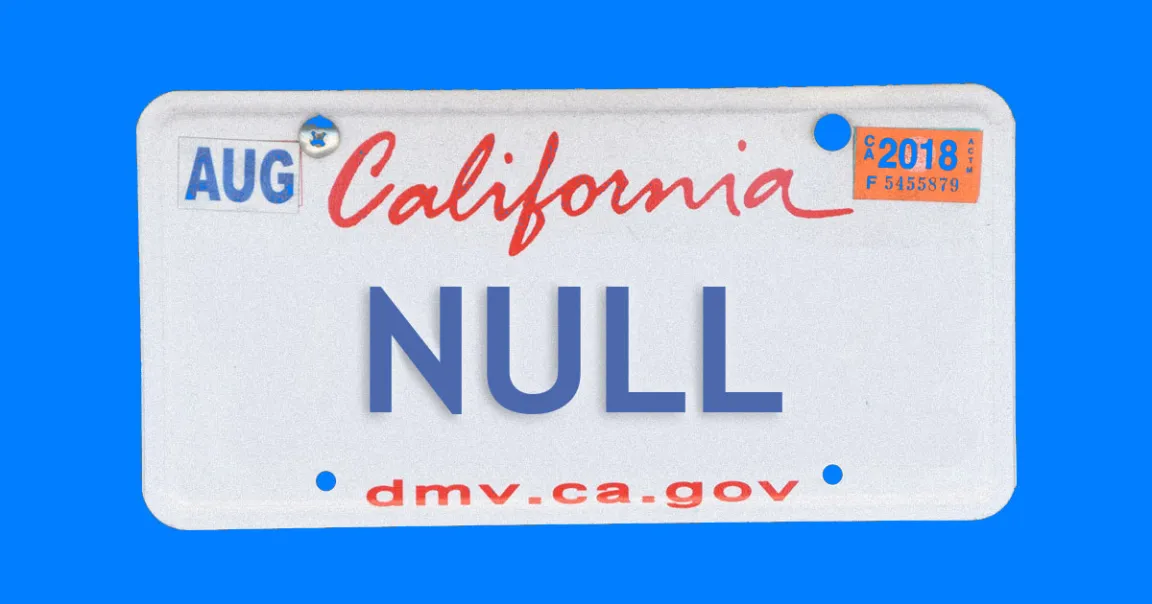

*TIL a California man got 'NULL' as a personalized license plate hoping that 'NULL' would confuse the computer system. Instead, when cops left the plate number info empty on a ticket or citation, the fine went to him. He got over $12k fines sent to him his first year.*


source: https://www.reddit.com/r/todayilearned/comments/gc14qg/til_a_california_man_got_null_as_a_personalized/

Other casse:

- Journalist Christopher Null: Websites removing his last name entirely


There are multiple **wrong ways** to handle missing values, such as:

- Replacing missing phone numbers with `000-000-0000`
- Replacing missing ZIP codes with `00000` or `99999`
- Replacing missing dates with `1900-01-01` or `9999-12-31`
- Replacing missing names with `"Unknown"` or `"N/A"`
- Replacing missing IDs with `0`
- Replacing missing ages with `-1` or `999`
- Replacing missing temperatures with `0` when `0` is also a valid measurement
- Replacing missing category values with `"Other"` even though `"Other"` is a real category
- Replacing missing text fields with an empty string `""` without marking them as missing
- Using `"NULL"` as plain text instead of a real missing-value marker
- Using `"No Tags"`, `"None"`, or `"Default"` as placeholders that could also be real values
- Mixing several placeholders in one dataset, such as `NULL`, `N/A`, `-999`, and empty strings for the same kind of missing data

## (ii) Filtering and Smoothing

Filtering and smoothing are about reducing random fluctuations in data and making the underlying trend more visible.

In [28]:
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter1d

## (iii) Binning and discretization

# Apple Daily Movement

This notebook loads Apple daily market data and builds simple daily movement features from open/close prices.

Dataset: `https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv`

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
df = pd.read_csv(url)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Daily movement features
df["daily_abs_move_usd"] = df["AAPL.Close"] - df["AAPL.Open"]
df["daily_pct_move"] = (df["AAPL.Close"] / df["AAPL.Open"] - 1.0) * 100.0
df["movement_class"] = np.where(df["daily_abs_move_usd"] >= 0, "Up", "Down")

display_cols = ["Date", "AAPL.Open", "AAPL.Close", "daily_abs_move_usd", "daily_pct_move", "movement_class"]
df[display_cols].head(10)

,Date,AAPL.Open,AAPL.Close,daily_abs_move_usd,daily_pct_move,movement_class
0,2015-02-17,127.489998,127.830002,0.340004,0.266691,Up
1,2015-02-18,127.629997,128.720001,1.090004,0.854034,Up
2,2015-02-19,128.479996,128.449997,-0.029999,-0.023349,Down
3,2015-02-20,128.619995,129.500000,0.880005,0.684190,Up
4,2015-02-23,130.020004,133.000000,2.979996,2.291952,Up
5,2015-02-24,132.940002,132.169998,-0.770004,-0.579212,Down
6,2015-02-25,131.559998,128.789993,-2.770005,-2.105507,Down
7,2015-02-26,128.789993,130.419998,1.630005,1.265630,Up
8,2015-02-27,130.000000,128.460007,-1.539993,-1.184610,Down
9,2015-03-02,129.250000,129.089996,-0.160004,-0.123794,Down


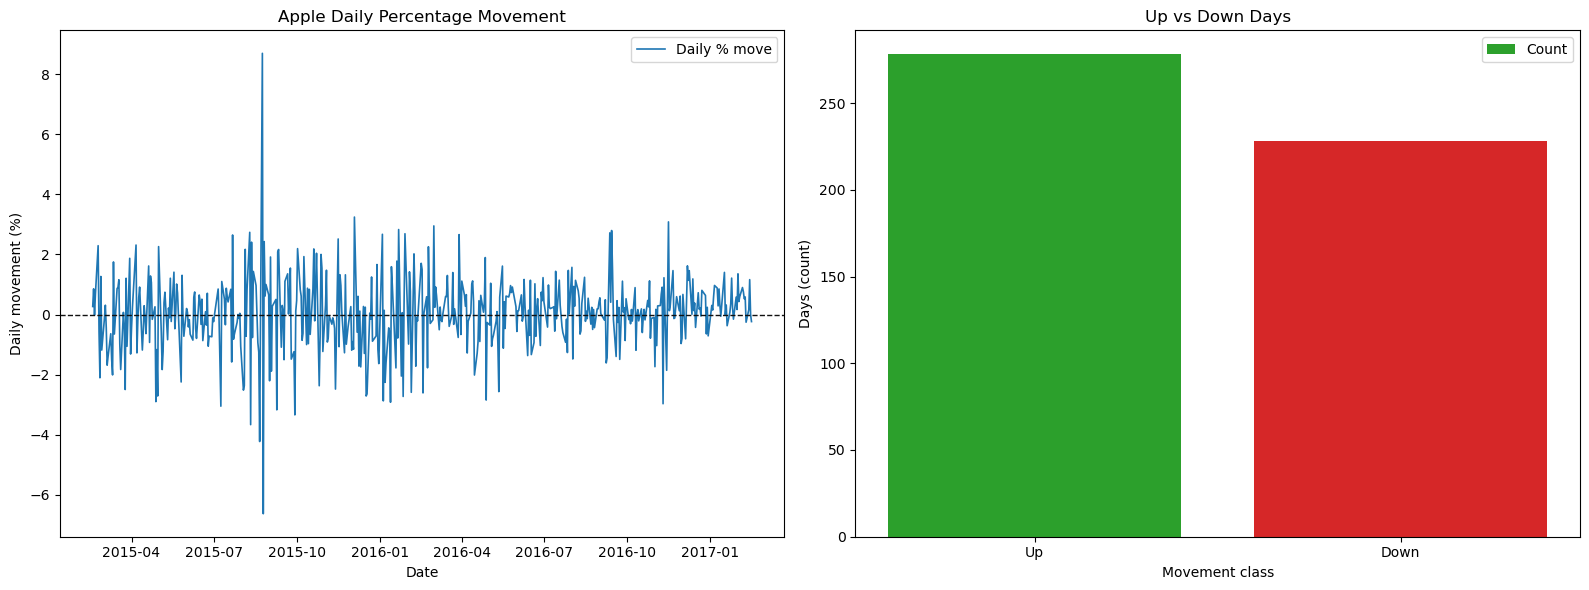

In [30]:
# Focused 2-chart layout (clear labels, high-contrast colors)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(df["Date"], df["daily_pct_move"], color="#1f77b4", linewidth=1.2, label="Daily % move")
ax1.axhline(0, color="#111111", linestyle="--", linewidth=1)
ax1.set_title("Apple Daily Percentage Movement")
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily movement (%)")
ax1.legend()

class_counts = df["movement_class"].value_counts().reindex(["Up", "Down"], fill_value=0)
ax2.bar(class_counts.index, class_counts.values, color=["#2ca02c", "#d62728"], label="Count")
ax2.set_title("Up vs Down Days")
ax2.set_xlabel("Movement class")
ax2.set_ylabel("Days (count)")
ax2.legend()

plt.tight_layout()
plt.show()

In [31]:
# Compact sanity checks
print("Rows:", len(df))
print("Missing values in core columns:")
print(df[["Date", "AAPL.Open", "AAPL.Close", "daily_abs_move_usd", "daily_pct_move", "movement_class"]].isna().sum())
print("\nMovement distribution:")
print(df["movement_class"].value_counts(normalize=True).rename("share"))

Rows: 506
Missing values in core columns:
Date                  0
AAPL.Open             0
AAPL.Close            0
daily_abs_move_usd    0
daily_pct_move        0
movement_class        0
dtype: int64

Movement distribution:
movement_class
Up      0.549407
Down    0.450593
Name: share, dtype: float64


## (iv) Missing value imputation:

Missing values (`NaN`) are one of the most common problems in real-world datasets. They can arise from **sensor failures**, **data entry errors**, or **incomplete surveys**.

### Why imputation matters

| Approach | Problem |
|---|---|
| **Drop rows** with `NaN` | Loss of valuable information, especially if many rows are affected |
| **Drop columns** with `NaN` | Entire features disappear, potentially losing predictive power |
| **Ignore** `NaN` values | Most ML models **cannot handle** missing values and will raise errors |

**Imputation** replaces missing values with reasonable estimates, preserving the dataset size and structure.

In this section we cover three practical strategies:

1. **Forward fill** (`ffill`) — propagate the last known value forward  
2. **Backward fill** (`bfill`) — propagate the next known value backward  
3. **Median imputation** — replace `NaN` with the column median  

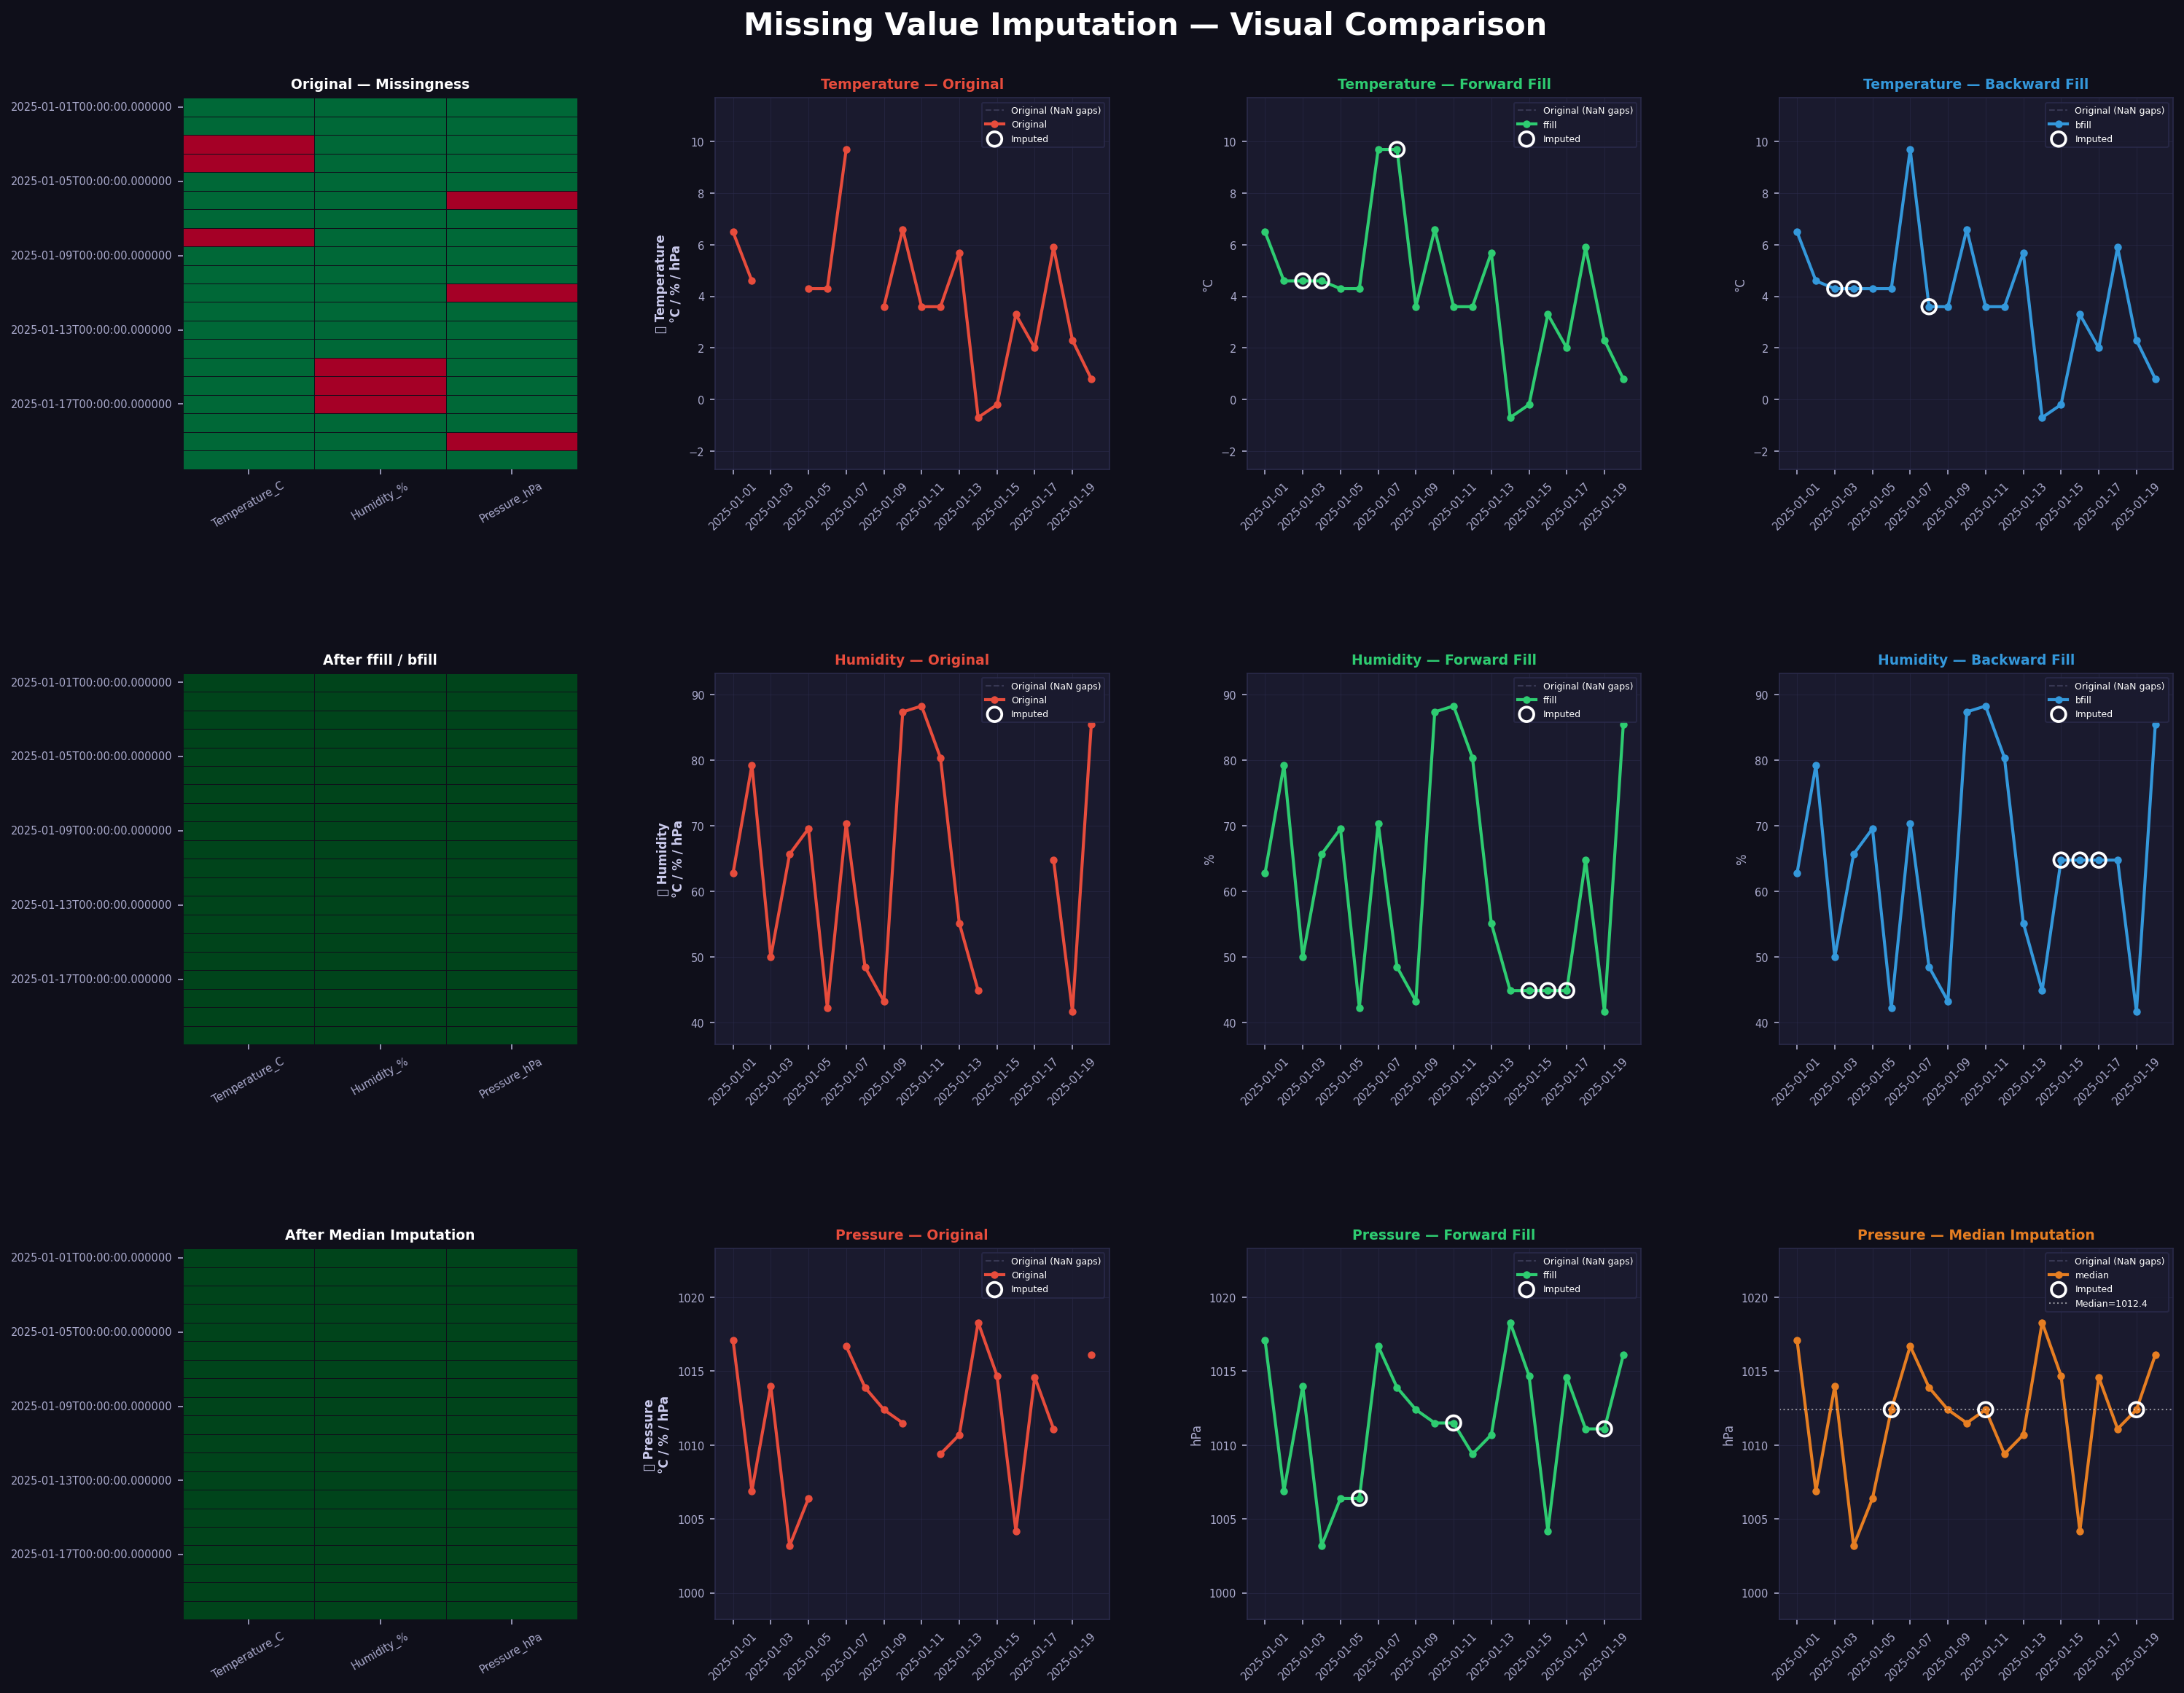

Dataset shape: (20, 3)

Missing values per column:
Temperature_C    3
Humidity_%       3
Pressure_hPa     3
dtype: int64



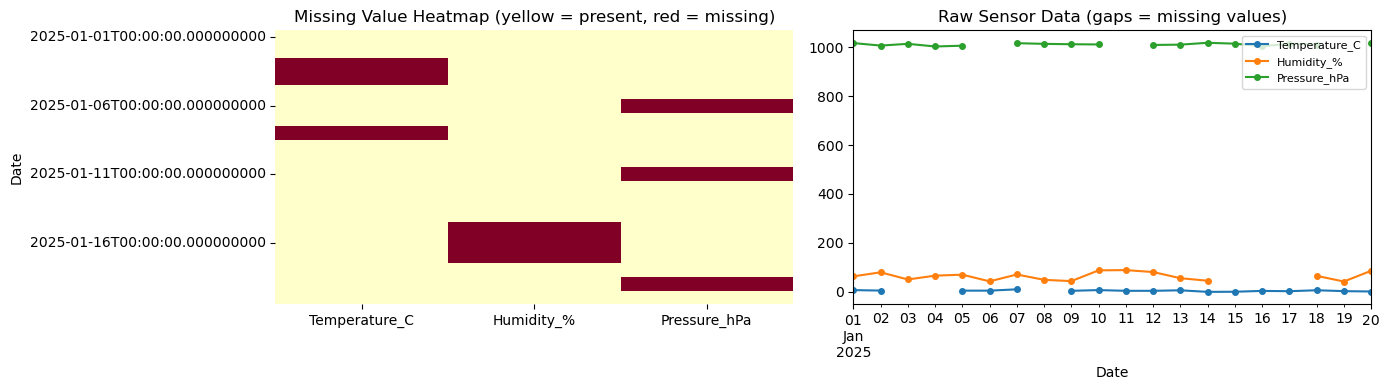

,Temperature_C,Humidity_%,Pressure_hPa
Date,,,
2025-01-01,6.5,62.8,1017.1
2025-01-02,4.6,79.3,1006.9
2025-01-03,NaN,50.0,1014.0
2025-01-04,NaN,65.7,1003.2
2025-01-05,4.3,69.6,1006.4
2025-01-06,4.3,42.3,NaN
2025-01-07,9.7,70.4,1016.7
2025-01-08,NaN,48.5,1013.9
2025-01-09,3.6,43.3,1012.4


In [32]:
# ── Create a sample dataset with missing values ─────────────────────────
import seaborn as sns

np.random.seed(42)

dates = pd.date_range('2025-01-01', periods=20, freq='D')
temperature = np.round(np.random.normal(loc=5, scale=3, size=20), 1)
humidity = np.round(np.random.uniform(40, 90, size=20), 1)
pressure = np.round(np.random.normal(loc=1013, scale=5, size=20), 1)

df = pd.DataFrame({
    'Date': dates,
    'Temperature_C': temperature,
    'Humidity_%': humidity,
    'Pressure_hPa': pressure
}).set_index('Date')

# Introduce missing values at realistic positions
df.loc[df.index[2:4], 'Temperature_C'] = np.nan   # two consecutive gaps
df.loc[df.index[7], 'Temperature_C'] = np.nan
df.loc[df.index[14:17], 'Humidity_%'] = np.nan     # three consecutive gaps
df.loc[df.index[5], 'Pressure_hPa'] = np.nan
df.loc[df.index[10], 'Pressure_hPa'] = np.nan
df.loc[df.index[18], 'Pressure_hPa'] = np.nan

print(f'Dataset shape: {df.shape}')
print(f'\nMissing values per column:\n{df.isna().sum()}\n')

# Visualise missingness pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap of missing values
sns.heatmap(df.isna(), cbar=False, cmap='YlOrRd', yticklabels=5, ax=axes[0])
axes[0].set_title('Missing Value Heatmap (yellow = present, red = missing)')

# Raw data plot with gaps
df.plot(ax=axes[1], marker='o', linewidth=1.5, markersize=4)
axes[1].set_title('Raw Sensor Data (gaps = missing values)')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
df.head(10)


### Forward Fill and Backward Fill

These are **propagation-based** imputation methods that are particularly useful for **time-series data** where adjacent values are likely similar.

#### Forward fill (`ffill`)

Replaces each `NaN` with the **most recent non-missing value** above it (i.e., the last valid observation is carried forward).

```
Before:  [1.0, 2.0, NaN, NaN, 5.0]
After:   [1.0, 2.0, 2.0, 2.0, 5.0]
```

```python
df.ffill()                     # pandas >= 2.0
df.fillna(method='ffill')      # older pandas versions
```

#### Backward fill (`bfill`)

Replaces each `NaN` with the **next non-missing value** below it.

```
Before:  [NaN, NaN, 3.0, NaN, 5.0]
After:   [3.0, 3.0, 3.0, 5.0, 5.0]
```

```python
df.bfill()
df.fillna(method='bfill')
```

> ⚠️ **Edge cases:**  
> - `ffill` **cannot** fill leading `NaN`s (no previous value exists)  
> - `bfill` **cannot** fill trailing `NaN`s (no next value exists)  
> - Use `limit=n` to restrict how far the fill propagates  


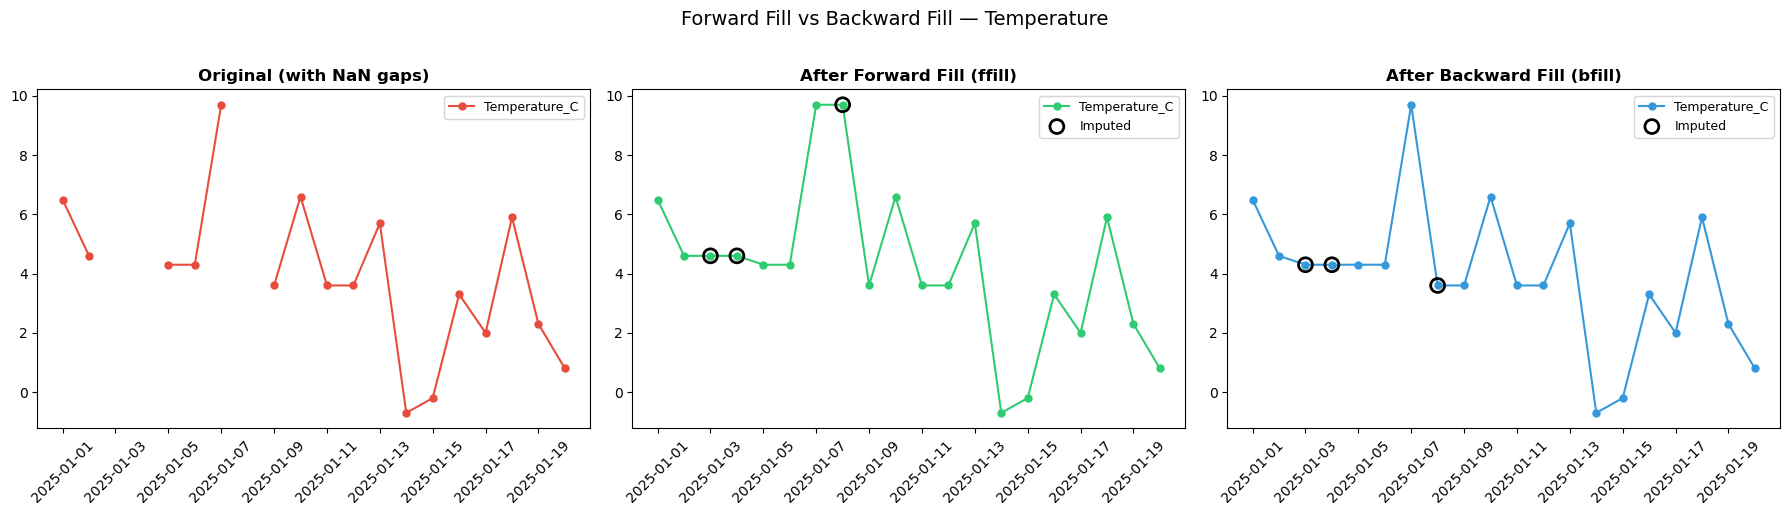

Rows where imputation occurred (Temperature_C):


,Original,ffill,bfill
Date,,,
2025-01-03,NaN,4.6,4.3
2025-01-04,NaN,4.6,4.3
2025-01-08,NaN,9.7,3.6


In [33]:
# ── Forward fill and backward fill ─────────────────────────────────────
df_ffill = df.ffill()
df_bfill = df.bfill()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, data, title, color in zip(
    axes,
    [df, df_ffill, df_bfill],
    ['Original (with NaN gaps)', 'After Forward Fill (ffill)', 'After Backward Fill (bfill)'],
    ['#e74c3c', '#2ecc71', '#3498db']
):
    # Plot the Temperature column as an example
    ax.plot(data.index, data['Temperature_C'], marker='o', color=color,
            linewidth=1.5, markersize=5, label='Temperature_C')
    # Highlight imputed points
    if 'ffill' in title or 'bfill' in title:
        mask = df['Temperature_C'].isna()
        ax.scatter(data.index[mask], data.loc[mask, 'Temperature_C'],
                   s=100, facecolors='none', edgecolors='black',
                   linewidths=2, zorder=5, label='Imputed')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Forward Fill vs Backward Fill — Temperature', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Show the numerical comparison
comparison = pd.DataFrame({
    'Original': df['Temperature_C'],
    'ffill': df_ffill['Temperature_C'],
    'bfill': df_bfill['Temperature_C'],
})
# Only show rows that had missing values
print('Rows where imputation occurred (Temperature_C):')
comparison[df['Temperature_C'].isna()]


### Median Imputation

Median imputation replaces every `NaN` in a column with the **median** of the non-missing values in that column.

$$\tilde{x} = \text{median}(x_1, x_2, \dots, x_n)$$

#### Why median instead of mean?

| | **Mean** | **Median** |
|---|---|---|
| Sensitive to outliers | Yes | No |
| Best for skewed data | No | Yes |
| Preserves central tendency | Yes (if symmetric) | Yes (always) |

The median is **robust** — a single extreme outlier does not shift it.

#### Implementation

```python
# Pure pandas
df.fillna(df.median())

# scikit-learn (useful in ML pipelines)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns, index=df.index
)
```

> 💡 **When to use median imputation:**  
> - Data has **no strong temporal ordering** (otherwise prefer ffill/bfill)  
> - Distribution is **skewed** or contains **outliers**  
> - You need a **simple, quick baseline** imputation  


Both methods identical: True

Column medians used for imputation:
Temperature_C       3.6
Humidity_%         64.8
Pressure_hPa     1012.4
dtype: float64


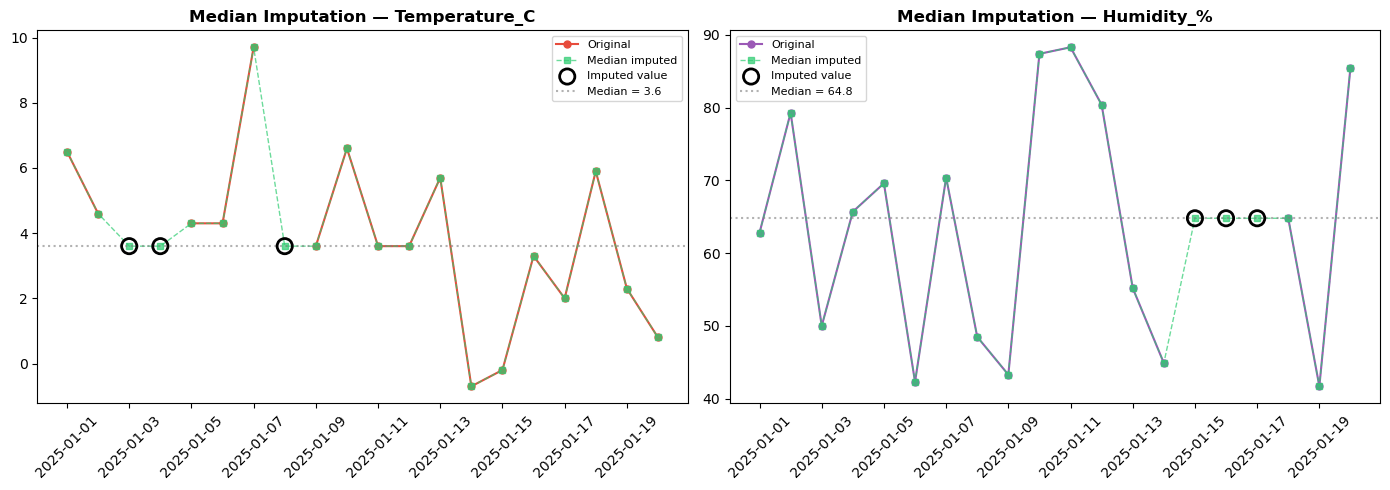

In [34]:
# ── Median imputation ──────────────────────────────────────────────────
from sklearn.impute import SimpleImputer

# Method 1: Pure pandas
df_median_pd = df.fillna(df.median(numeric_only=True))

# Method 2: scikit-learn SimpleImputer
imputer = SimpleImputer(strategy='median')
df_median_sk = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns,
    index=df.index
)

# Verify both methods give the same result
print('Both methods identical:', df_median_pd.equals(df_median_sk))
print(f'\nColumn medians used for imputation:')
print(df.median(numeric_only=True))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ['Temperature_C', 'Humidity_%'], ['#e74c3c', '#9b59b6']):
    ax.plot(df.index, df[col], marker='o', color=color,
            linewidth=1.5, markersize=5, label='Original')
    ax.plot(df_median_pd.index, df_median_pd[col], marker='s', color='#2ecc71',
            linewidth=1, markersize=4, linestyle='--', alpha=0.7, label='Median imputed')
    # Highlight imputed points
    mask = df[col].isna()
    ax.scatter(df_median_pd.index[mask], df_median_pd.loc[mask, col],
               s=120, facecolors='none', edgecolors='black',
               linewidths=2, zorder=5, label='Imputed value')
    # Draw median line
    med_val = df[col].median()
    ax.axhline(y=med_val, color='gray', linestyle=':', alpha=0.6,
               label=f'Median = {med_val:.1f}')
    ax.set_title(f'Median Imputation — {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


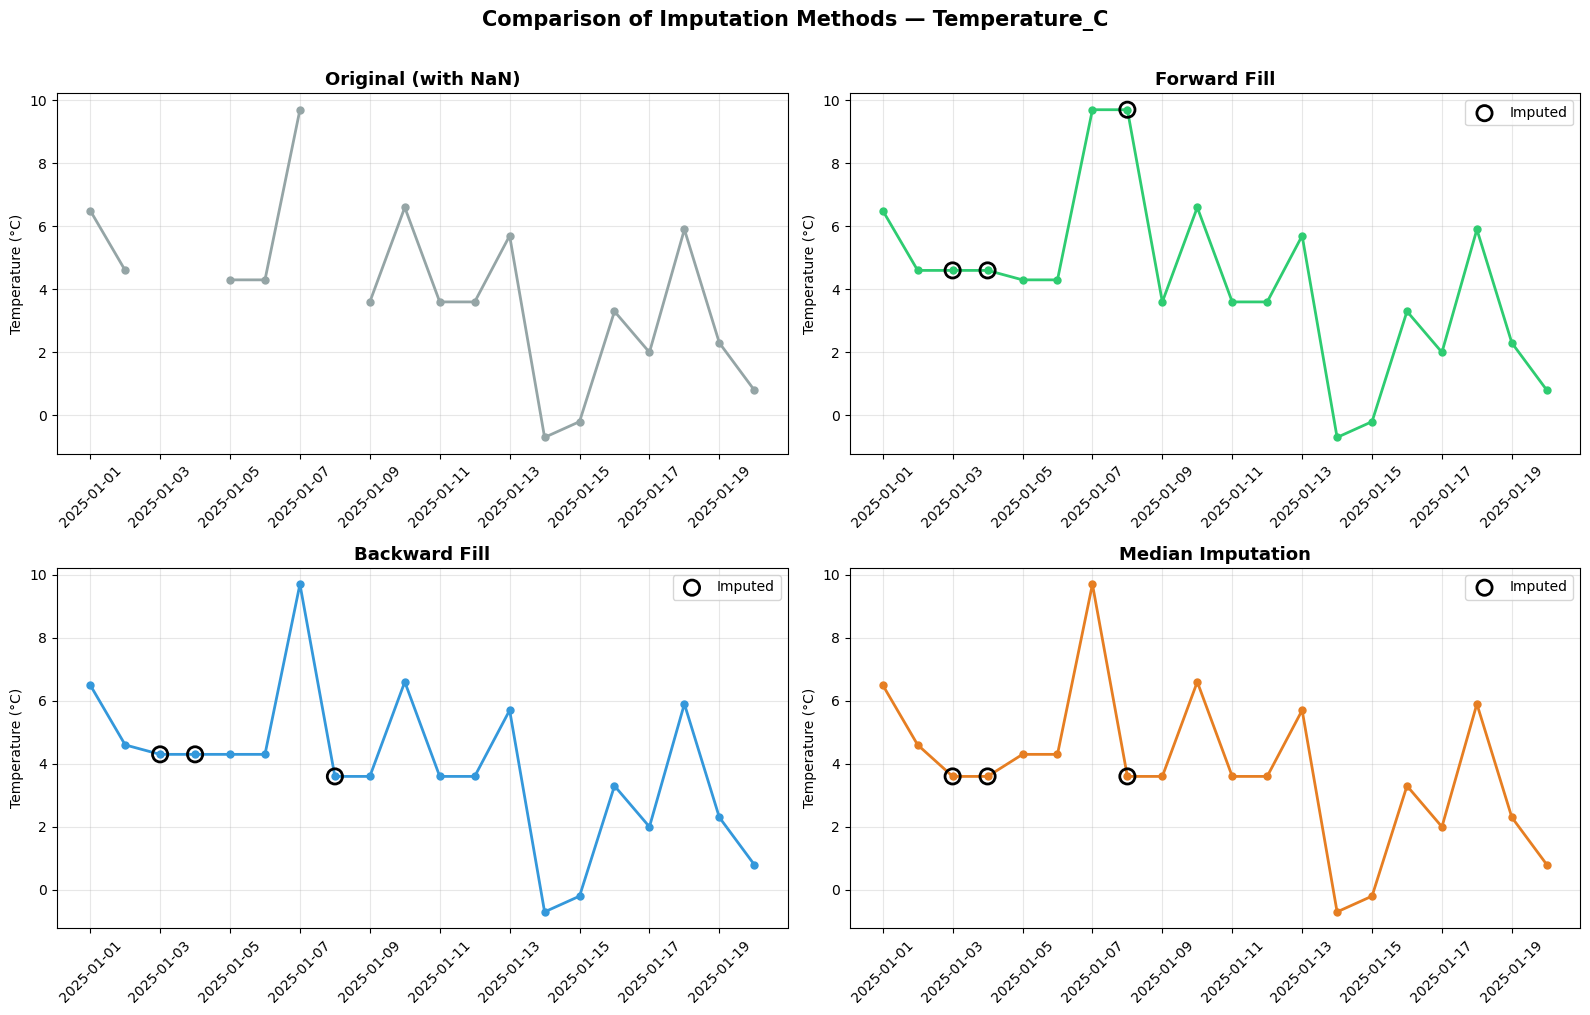

In [35]:
# ── Combined comparison of all three methods ──────────────────────────
col = 'Temperature_C'  # Use Temperature as our example column

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

methods = {
    'Original (with NaN)': (df, '#95a5a6'),
    'Forward Fill': (df_ffill, '#2ecc71'),
    'Backward Fill': (df_bfill, '#3498db'),
    'Median Imputation': (df_median_pd, '#e67e22'),
}

mask = df[col].isna()

for ax, (title, (data, color)) in zip(axes.flat, methods.items()):
    ax.plot(data.index, data[col], marker='o', color=color,
            linewidth=2, markersize=5)
    if 'Original' not in title:
        ax.scatter(data.index[mask], data.loc[mask, col],
                   s=120, facecolors='none', edgecolors='black',
                   linewidths=2, zorder=5, label='Imputed')
        ax.legend(fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Temperature (°C)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparison of Imputation Methods — Temperature_C',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



### Summary: Choosing the Right Imputation Method

| Method | Best For | Limitation |
|---|---|---|
| **Forward fill** (`ffill`) | Time-series with gradual changes | Cannot fill leading `NaN`s; may be inaccurate across long gaps |
| **Backward fill** (`bfill`) | Time-series where future context is available | Cannot fill trailing `NaN`s; rarely used alone |
| **Median imputation** | Cross-sectional data; data with outliers or skew | Ignores temporal structure; reduces variance |

#### Key Takeaways

- **Always visualize** your missing data pattern first (`sns.heatmap(df.isna())`) — the pattern dictates the method.
- **Forward/backward fill** preserves local trends but is **only valid when adjacent values are similar** (e.g., sensor data, stock prices).
- **Median imputation** is **robust to outliers** and works well as a quick baseline, but it **flattens the distribution** and ignores correlations between features.
- For production ML pipelines, consider using `sklearn.impute.SimpleImputer` so imputation is part of a reproducible `Pipeline`.
- More advanced methods (e.g., KNN imputation, iterative imputation) exist for complex missing data patterns.


## (v) Outlier detection and removal

### Boxplots



An useful way of detecting outliers is by using a boxplot, that way we can see the distribution of the data using quartiles, and the points outside the 'whiskers' of the plot are the outliers.

In [36]:
# diabetes = load_diabetes()

# column_name = diabetes.feature_names
# df_diabetics = pd.DataFrame(diabetes.data, columns=column_name)

# sns.boxplot(df_diabetics['bmi'])
# plt.title('Boxplot of BMI')
# plt.show()

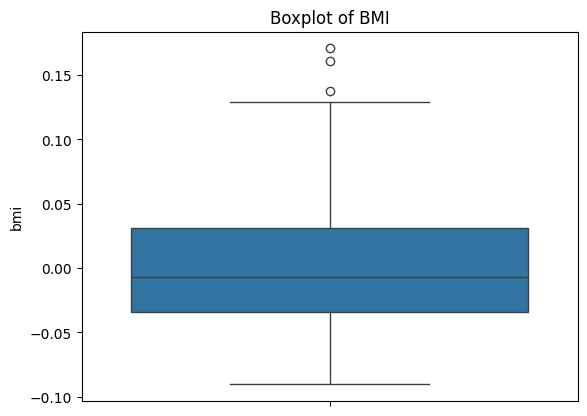

As we can see in the plot we have three points outside of the top whisker, these values are much higher than the rest of the data, from the plot we could infer that bmi values above 0.12 could be identified as outliers

To remove them we can define a threshold (say, anything greater than X) and filter the data.

In [37]:
# def removal_box_plot(df, column, threshold):
#     removed_outliers = df[df[column] <= threshold]

#     sns.boxplot(removed_outliers[column])
#     plt.title(f'Box Plot without Outliers of {column}')
#     plt.show()
#     return removed_outliers


# threshold_value = 0.12

# no_outliers = removal_box_plot(df_diabetics, 'bmi', threshold_value)

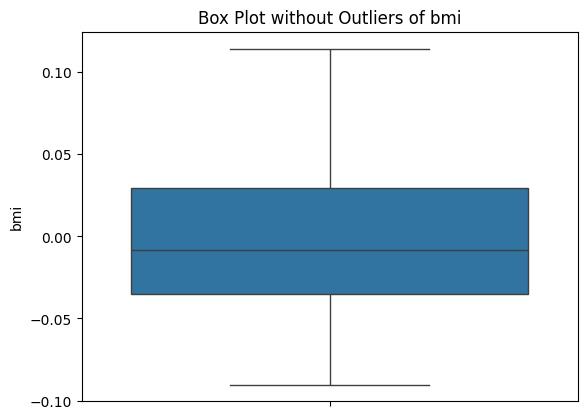

Other methods:
- Scatter Plots
- Z-Score
- Interquartile Range Method

## (vi) Data integration: merging pandas dataframes

Pandas provides several methods in order to combine dataframes, namely:
- concat(): Merge multiple Series or DataFrame objects along a shared index or column

- DataFrame.join(): Merge multiple DataFrame objects along the columns

- DataFrame.combine_first(): Update missing values with non-missing values in the same location

- merge(): Combine two Series or DataFrame objects with SQL-style joining

- merge_ordered(): Combine two Series or DataFrame objects along an ordered axis

- merge_asof(): Combine two Series or DataFrame objects by near instead of exact matching keys


### Method concat()

Stacking tables across an axis (rows default)

In [38]:
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)


df2 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[4, 5, 6, 7],
)


df3 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)


frames = [df1, df2, df3]

result = pd.concat(frames)

result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


### Method merge()
Works like joining tables in SQL (using a common column (key)). Matches rows baed on a column.

## Moving Average

Noise is present in sensor and measurement data and can cause models to learn unimportant random effects. An important method for attenuating this noise is the moving average.

Each data point is replaced by the average of several neighboring values. This smooths out short-term fluctuations while preserving the general trend of the data.

In [39]:
data = pd.Series([10, 12, 11, 13, 12, 14, 13])
smoothed = data.rolling(window=3).mean() # Moving average mit Fenstergrösse 3
# smoothed = data.ewm(span=3).mean() # Exponentiell gewichteter gleitender Durchschnitt mit Fenstergrösse 3
smoothed

0     NaN
1     NaN
2    11.0
3    12.0
4    12.0
5    13.0
6    13.0
dtype: float64

The advantage of EWM (exponential moving average) is that it does not only consider a fixed window of values, but calculates the average recursively – each new value is combined with the previous average. This has the advantage that no NaN values can occur.

With a normal moving average, you first need enough values to fill the window. With a window of 3, the average can only be calculated from the third value onwards – the first two positions therefore become NaN.

## Discrete-time data

For discrete, non-time-dependent data, other tools are used, which tend to originate from statistics and signal processing.

### Median-Filter

Instead of calculating the average, the median of a local neighborhood is used. This is robust against individual extreme values and also works very well with discrete data.

The median has a charming property: individual extreme values have little influence on the result. That is why it is often used for discrete data or image processing.

In [40]:
data = pd.Series([1, 2, 2, 3, 100, 3, 2, 2, 1])
smoothed = data.rolling(window=3).median()
smoothed

0    NaN
1    NaN
2    2.0
3    2.0
4    3.0
5    3.0
6    3.0
7    2.0
8    2.0
dtype: float64

### Kernel-Smoothing

Each point is replaced by a weighted combination of its neighbors. Points that are closer are given more weight than those that are further away. A commonly used kernel is the Gaussian kernel, which uses a bell-shaped weighting.

In [41]:
data = np.array([1,2,2,3,4,3,2,2,1])
smoothed = gaussian_filter1d(data, sigma=1)
smoothed

array([1, 1, 2, 2, 3, 2, 2, 1, 1])

### Binning-basierte Glättung

Data is grouped into intervals (bins) and replaced within each bin by a representative value, such as the mean or median of the bin. This eliminates small random differences between very similar values.

This is particularly useful for features such as age, income, or rating scales, where many similar values exist and small differences are of little significance to a model.

In [42]:
data = pd.Series([21,22,22,23,24,25,26,27])
bins = pd.cut(data, bins=3)
smoothed = data.groupby(bins).transform("mean")
smoothed

C:\Users\fabia\AppData\Local\Temp\ipykernel_12148\1261214620.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = data.groupby(bins).transform("mean")


0    22.0
1    22.0
2    22.0
3    22.0
4    24.5
5    24.5
6    26.5
7    26.5
dtype: float64